# Анализ продаж и покупателей

В этом ноутбуке я проанализирую динамику продаж, поведение покупателей, повторные покупки, когорты и RFM-сегменты.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## Загрузка данных

In [2]:
df = pd.read_pickle('online_retail_clean.pkl')
df.shape

(1055238, 13)

Для анализа продаж оставим только обычные товарные операции с положительным количеством и ценой.

In [3]:
sales = df[(~df['is_cancelled']) & (~df['is_service']) & (df['quantity'] > 0) & (df['price'] > 0)].copy()
customer_sales = sales[sales['customer_id'].notna()].copy()

print('Строк продаж:', len(sales))
print('Строк с известным покупателем:', len(customer_sales))

Строк продаж: 1025074
Строк с известным покупателем: 790739


In [4]:
print('Период:', sales['invoice_date'].min(), '-', sales['invoice_date'].max())
print('Счетов:', sales['invoice'].nunique())
print('Покупателей:', customer_sales['customer_id'].nunique())
print('Товаров:', sales['stock_code'].nunique())
print('Выручка:', round(sales['line_total'].sum(), 2))

Период: 2009-12-01 07:45:00 - 2011-12-09 12:50:00
Счетов: 39555
Покупателей: 5861
Товаров: 4904
Выручка: 20063266.75


## Динамика продаж по месяцам

Рассчитаем выручку, количество счетов и средний чек по месяцам.

In [5]:
sales['month'] = sales['invoice_date'].dt.to_period('M').dt.to_timestamp()

In [6]:
monthly_sales = sales.groupby('month').agg(revenue=('line_total', 'sum'), invoices=('invoice', 'nunique')).reset_index()
monthly_sales['average_invoice'] = monthly_sales['revenue'] / monthly_sales['invoices']

monthly_sales

,month,revenue,invoices,average_invoice
0,2009-12-01,"798,118.53",1666,479.06
1,2010-01-01,"621,263.43",1085,572.59
2,2010-02-01,"537,932.64",1189,452.42
3,2010-03-01,"761,748.53",1647,462.51
4,2010-04-01,"646,455.56",1435,450.49
5,2010-05-01,"643,585.64",1484,433.68
6,2010-06-01,"697,384.87",1615,431.82
7,2010-07-01,"633,079.42",1507,420.09
8,2010-08-01,"674,192.89",1402,480.88
9,2010-09-01,"869,277.16",1789,485.90


Данные начинаются в декабре 2009 года и заканчиваются в декабре 2011 года. Первый и последний месяцы представлены не полностью, поэтому при сравнении месячной динамики их нужно учитывать отдельно.

In [7]:
full_months = monthly_sales[(monthly_sales['month'] > '2009-12-01') & (monthly_sales['month'] < '2011-12-01')].copy()

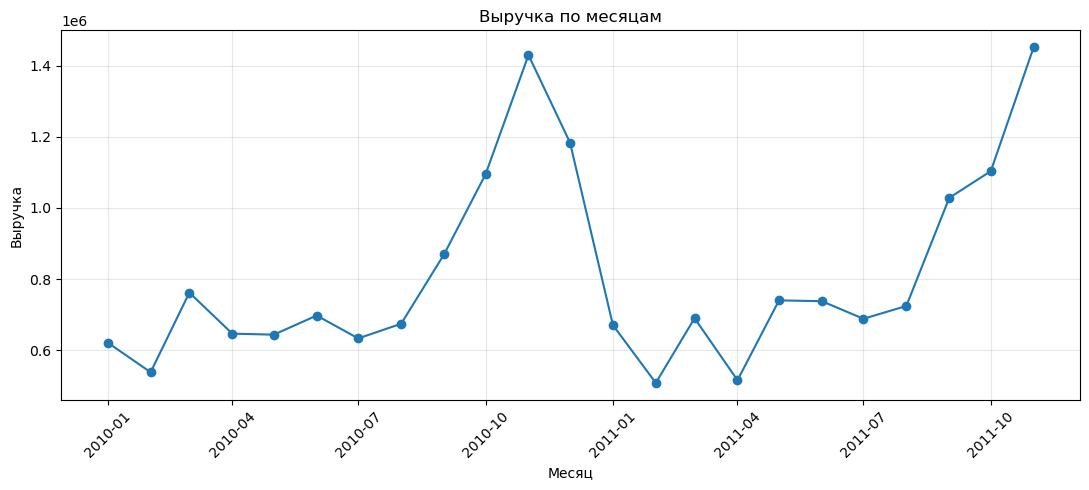

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(full_months['month'], full_months['revenue'], marker='o')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

По графику видно, что выручка меняется неравномерно в течение года.

В 2010 и 2011 годах рост начинается ближе к осени, а максимальные значения наблюдаются в ноябре. После высокого уровня в конце года выручка снижается в январе и феврале.

Такая динамика может быть связана с сезонным спросом и покупками перед зимними праздниками. Однако по одному графику нельзя точно определить причину роста, поэтому дальше стоит сравнить количество счетов и средний чек.

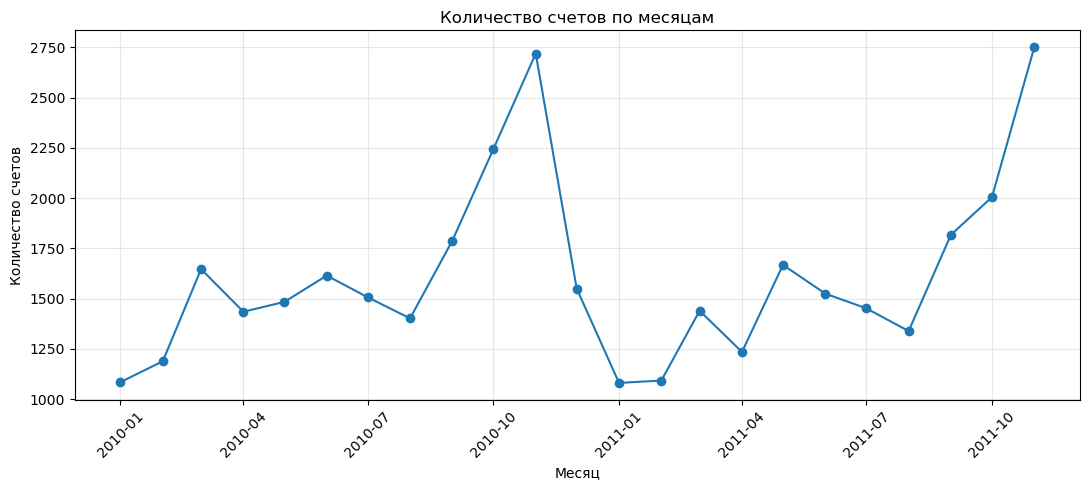

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(full_months['month'], full_months['invoices'], marker='o')
plt.title('Количество счетов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество счетов')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

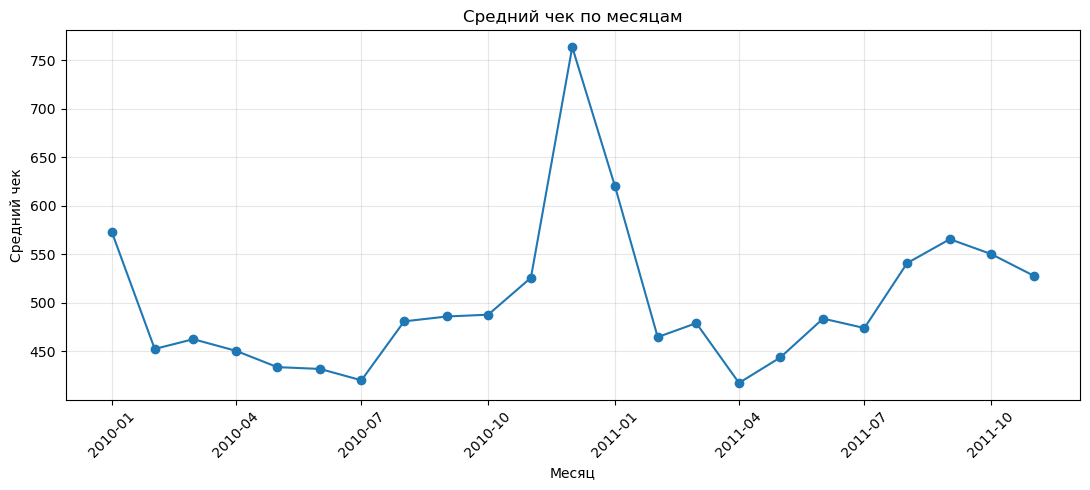

In [10]:
plt.figure(figsize=(11, 5))
plt.plot(full_months['month'], full_months['average_invoice'], marker='o')
plt.title('Средний чек по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
full_months.loc[full_months['revenue'].idxmax()]

month              2011-11-01 00:00:00
revenue                   1,452,115.98
invoices                          2751
average_invoice                 527.85
Name: 23, dtype: object

In [12]:
full_months.loc[full_months['revenue'].idxmin()]

month              2011-02-01 00:00:00
revenue                     507,866.54
invoices                          1093
average_invoice                 464.65
Name: 14, dtype: object

## Сравнение выручки по годам

Сравним выручку одинаковых месяцев 2010 и 2011 годов.

In [13]:
monthly_sales['year'] = monthly_sales['month'].dt.year
monthly_sales['month_number'] = monthly_sales['month'].dt.month

In [14]:
year_comparison = monthly_sales[(monthly_sales['year'].isin([2010, 2011])) & (monthly_sales['month_number'] <= 11)].pivot(index='month_number', columns='year', values='revenue')
year_comparison

year,2010,2011
month_number,,
1,"621,263.43","670,439.46"
2,"537,932.64","507,866.54"
3,"761,748.53","689,841.84"
4,"646,455.56","515,469.66"
5,"643,585.64","740,036.33"
6,"697,384.87","737,683.99"
7,"633,079.42","688,252.67"
8,"674,192.89","724,308.16"
9,"869,277.16","1,028,345.38"


In [15]:
year_comparison['growth_pct'] = (year_comparison[2011] / year_comparison[2010] - 1) * 100
year_comparison.round(2)

year,2010,2011,growth_pct
month_number,,,
1,"621,263.43","670,439.46",7.92
2,"537,932.64","507,866.54",-5.59
3,"761,748.53","689,841.84",-9.44
4,"646,455.56","515,469.66",-20.26
5,"643,585.64","740,036.33",14.99
6,"697,384.87","737,683.99",5.78
7,"633,079.42","688,252.67",8.72
8,"674,192.89","724,308.16",7.43
9,"869,277.16","1,028,345.38",18.30


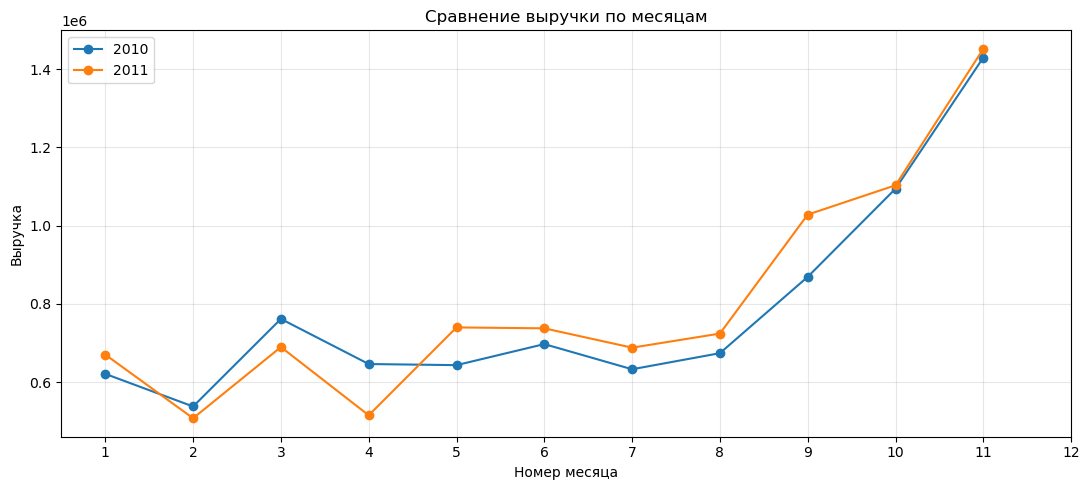

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(year_comparison.index, year_comparison[2010], marker='o', label='2010')
plt.plot(year_comparison.index, year_comparison[2011], marker='o', label='2011')
plt.title('Сравнение выручки по месяцам')
plt.xlabel('Номер месяца')
plt.ylabel('Выручка')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Повторные покупки

Посчитаем, сколько покупателей совершили больше одного заказа.

In [17]:
customer_orders = customer_sales.groupby('customer_id')['invoice'].nunique().reset_index(name='orders_count')

customer_orders.head()

,customer_id,orders_count
0,12346,3
1,12347,8
2,12348,5
3,12349,3
4,12350,1


In [18]:
buyers_count = len(customer_orders)
repeat_buyers_count = (customer_orders['orders_count'] > 1).sum()
repeat_buyer_rate = repeat_buyers_count / buyers_count * 100

print('Всего покупателей:', buyers_count)
print('Повторных покупателей:', repeat_buyers_count)
print('Доля повторных покупателей:', round(repeat_buyer_rate, 2), '%')

Всего покупателей: 5861
Повторных покупателей: 4236
Доля повторных покупателей: 72.27 %


In [19]:
customer_orders['orders_count'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   5,861.00
mean        6.25
std        12.77
min         1.00
50%         3.00
75%         7.00
90%        13.00
95%        20.00
99%        46.00
max       376.00
Name: orders_count, dtype: float64

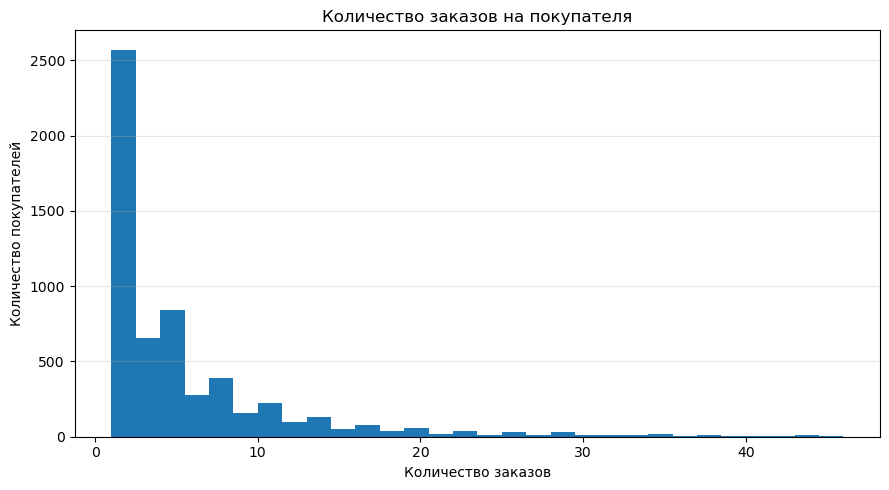

In [20]:
limit = customer_orders['orders_count'].quantile(0.99)

plt.figure(figsize=(9, 5))
plt.hist(customer_orders.loc[customer_orders['orders_count'] <= limit, 'orders_count'], bins=30)
plt.title('Количество заказов на покупателя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество покупателей')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
order_groups = pd.Series({'1 заказ': (customer_orders['orders_count'] == 1).sum(), '2–5 заказов': customer_orders['orders_count'].between(2, 5).sum(), '6–10 заказов': customer_orders['orders_count'].between(6, 10).sum(), 'Больше 10': (customer_orders['orders_count'] > 10).sum()})

order_groups

1 заказ         1625
2–5 заказов     2449
6–10 заказов     922
Больше 10        865
dtype: int64

In [22]:
(order_groups / order_groups.sum() * 100).round(2)

1 заказ        27.73
2–5 заказов    41.78
6–10 заказов   15.73
Больше 10      14.76
dtype: float64

Большинство покупателей совершили больше одного заказа: доля повторных покупателей составила 72,27%.

Самая крупная группа — покупатели с 2–5 заказами, их доля составляет 41,78%. При этом 14,76% покупателей сделали больше 10 заказов, что указывает на наличие заметной группы постоянных клиентов.

## Когортный анализ

Разделим покупателей на когорты по месяцу первой покупки и посмотрим, какая доля клиентов возвращалась в следующие месяцы.

In [23]:
orders = customer_sales[['customer_id', 'invoice', 'invoice_date']].drop_duplicates()
orders['order_month'] = orders['invoice_date'].dt.to_period('M').dt.to_timestamp()

In [24]:
first_orders = orders.groupby('customer_id')['order_month'].min().reset_index(name='cohort_month')
orders = orders.merge(first_orders, on='customer_id', how='left')

In [25]:
orders['cohort_index'] = (orders['order_month'].dt.year - orders['cohort_month'].dt.year) * 12 + orders['order_month'].dt.month - orders['cohort_month'].dt.month

In [26]:
cohort_data = orders.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index(name='customers')
cohort_sizes = cohort_data[cohort_data['cohort_index'] == 0][['cohort_month', 'customers']].rename(columns={'customers': 'cohort_size'})
cohort_data = cohort_data.merge(cohort_sizes, on='cohort_month')
cohort_data['retention'] = cohort_data['customers'] / cohort_data['cohort_size']

In [27]:
retention_table = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='retention')
retention_table.round(3)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12-01,1.00,0.35,0.33,0.42,0.38,0.36,0.38,0.34,0.34,0.36,0.42,0.50,0.38,0.28,0.24,0.30,0.26,0.30,0.28,0.26,0.25,0.31,0.30,0.41,0.20
2010-01-01,1.00,0.21,0.31,0.31,0.26,0.30,0.26,0.23,0.28,0.32,0.30,0.17,0.22,0.17,0.19,0.15,0.24,0.20,0.19,0.20,0.24,0.19,0.25,0.06,NaN
2010-02-01,1.00,0.23,0.23,0.29,0.24,0.20,0.19,0.29,0.26,0.28,0.12,0.12,0.15,0.18,0.12,0.20,0.16,0.16,0.14,0.23,0.23,0.17,0.06,NaN,NaN
2010-03-01,1.00,0.19,0.23,0.24,0.23,0.20,0.24,0.30,0.28,0.11,0.12,0.14,0.20,0.16,0.20,0.17,0.17,0.16,0.18,0.20,0.21,0.08,NaN,NaN,NaN
2010-04-01,1.00,0.19,0.19,0.16,0.18,0.22,0.28,0.26,0.11,0.11,0.07,0.14,0.14,0.16,0.16,0.16,0.14,0.15,0.18,0.23,0.06,NaN,NaN,NaN,NaN
2010-05-01,1.00,0.16,0.17,0.17,0.18,0.26,0.21,0.13,0.06,0.08,0.11,0.13,0.15,0.15,0.10,0.13,0.14,0.17,0.15,0.05,NaN,NaN,NaN,NaN,NaN
2010-06-01,1.00,0.18,0.19,0.21,0.23,0.28,0.13,0.09,0.08,0.11,0.10,0.14,0.15,0.12,0.11,0.12,0.13,0.20,0.05,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,1.00,0.16,0.18,0.30,0.29,0.14,0.11,0.15,0.15,0.11,0.14,0.15,0.13,0.14,0.20,0.17,0.24,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,1.00,0.20,0.29,0.33,0.17,0.12,0.10,0.13,0.14,0.13,0.13,0.12,0.15,0.17,0.17,0.20,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Когорта декабря 2009 года отличается более высоким удержанием. Поскольку это первый месяц наблюдений, первая покупка в датасете могла не быть первой покупкой клиента в магазине. Поэтому эту когорту не будем использовать для сравнения с остальными.

Пустые значения у последних когорт означают, что для расчёта соответствующего периода ещё недостаточно данных. Retention рассчитывается отдельно для каждого месяца, поэтому он не обязан постоянно снижаться.

### Карта удержания

На карте показан retention в первые шесть месяцев после первой покупки. Когорта декабря 2009 года исключена из-за неполной истории до начала датасета.

In [28]:
retention_heatmap = retention_table.loc['2010-01-01':'2011-05-01', 1:6] * 100

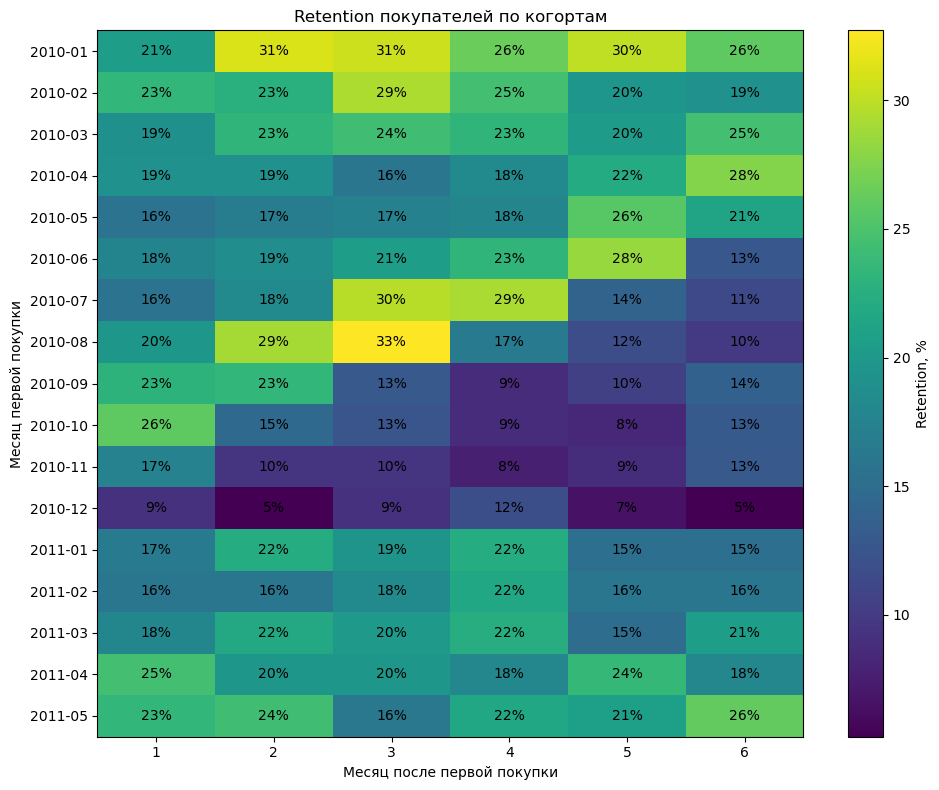

In [29]:
plt.figure(figsize=(10, 8))
plt.imshow(retention_heatmap, aspect='auto')
plt.title('Retention покупателей по когортам')
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Месяц первой покупки')
plt.xticks(range(len(retention_heatmap.columns)), retention_heatmap.columns)
plt.yticks(range(len(retention_heatmap.index)), retention_heatmap.index.strftime('%Y-%m'))

for i in range(len(retention_heatmap.index)):
    for j in range(len(retention_heatmap.columns)):
        value = retention_heatmap.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f'{value:.0f}%', ha='center', va='center')

plt.colorbar(label='Retention, %')
plt.tight_layout()
plt.show()

В большинстве когорт retention в первые шесть месяцев находится примерно в диапазоне 15–25%.

Наиболее высокие значения встречаются у когорт начала 2010 года и некоторых летних когорт. Когорта декабря 2010 года показывает заметно более низкое удержание: от 5% до 12% в последующие месяцы.

Низкий retention декабрьской когорты может быть связан с разовыми покупками перед праздниками, однако это только гипотеза. Для проверки понадобились бы данные о категориях товаров, маркетинговых кампаниях и каналах привлечения.

Retention не снижается строго от месяца к месяцу, поскольку покупатель может пропустить один месяц и вернуться позже.

In [30]:
retention_summary = retention_table.loc['2010-01-01':'2011-05-01', [1, 3, 6]] * 100
retention_summary.columns = ['month_1', 'month_3', 'month_6']

retention_summary.round(1)

,month_1,month_3,month_6
cohort_month,,,
2010-01-01,20.70,30.60,25.90
2010-02-01,23.50,29.30,19.20
2010-03-01,19.10,24.30,24.50
2010-04-01,19.10,16.00,27.60
2010-05-01,15.70,17.30,21.30
2010-06-01,17.60,20.60,12.70
2010-07-01,15.70,29.70,11.40
2010-08-01,19.80,32.70,9.90
2010-09-01,23.00,13.00,13.80


In [31]:
retention_summary.mean().round(2)

month_1   19.13
month_3   19.94
month_6   17.27
dtype: float64

## RFM-анализ

Разделим покупателей на группы по трём показателям:

- `recency` — сколько дней прошло с последней покупки;
- `frequency` — количество счетов покупателя;
- `monetary` — общая сумма покупок.

In [32]:
analysis_date = customer_sales['invoice_date'].max() + pd.Timedelta(days=1)

In [33]:
rfm = customer_sales.groupby('customer_id').agg(last_purchase=('invoice_date', 'max'), frequency=('invoice', 'nunique'), monetary=('line_total', 'sum')).reset_index()
rfm['recency'] = (analysis_date - rfm['last_purchase']).dt.days
rfm = rfm[['customer_id', 'recency', 'frequency', 'monetary']]

rfm.head()

,customer_id,recency,frequency,monetary
0,12346,326,3,"77,352.96"
1,12347,2,8,"5,633.32"
2,12348,75,5,"1,658.40"
3,12349,19,3,"3,678.69"
4,12350,310,1,294.40


In [34]:
rfm[['recency', 'frequency', 'monetary']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,99%,max
recency,"5,861.00",200.94,209.20,1.00,26.00,96.00,379.00,534.00,726.00,739.00
frequency,"5,861.00",6.25,12.77,1.00,1.00,3.00,7.00,13.00,46.00,376.00
monetary,"5,861.00","2,965.56","14,592.54",2.95,341.90,874.25,"2,279.49","5,482.57","28,616.33","608,821.65"


### Расчёт RFM-оценок

Каждому покупателю присвоим оценку от 1 до 4.

Для `recency` меньшие значения считаются лучшими, а для `frequency` и `monetary` — большие.

In [35]:
r_quantiles = rfm['recency'].quantile([0.25, 0.5, 0.75])
f_quantiles = rfm['frequency'].quantile([0.25, 0.5, 0.75])
m_quantiles = rfm['monetary'].quantile([0.25, 0.5, 0.75])

In [36]:
def get_r_score(value):
    if value <= r_quantiles[0.25]:
        return 4
    if value <= r_quantiles[0.5]:
        return 3
    if value <= r_quantiles[0.75]:
        return 2
    return 1

In [37]:
def get_score(value, quantiles):
    if value <= quantiles[0.25]:
        return 1
    if value <= quantiles[0.5]:
        return 2
    if value <= quantiles[0.75]:
        return 3
    return 4

In [38]:
rfm['r_score'] = rfm['recency'].apply(get_r_score)
rfm['f_score'] = rfm['frequency'].apply(get_score, quantiles=f_quantiles)
rfm['m_score'] = rfm['monetary'].apply(get_score, quantiles=m_quantiles)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,12346,326,3,"77,352.96",2,2,4,8
1,12347,2,8,"5,633.32",4,4,4,12
2,12348,75,5,"1,658.40",3,3,3,9
3,12349,19,3,"3,678.69",4,2,4,10
4,12350,310,1,294.40,2,1,1,4


In [39]:
rfm[['r_score', 'f_score', 'm_score', 'rfm_score']].describe().T

,count,mean,std,min,25%,50%,75%,max
r_score,"5,861.00",2.51,1.12,1.00,2.00,3.00,4.00,4.00
f_score,"5,861.00",2.39,1.11,1.00,1.00,2.00,3.00,4.00
m_score,"5,861.00",2.50,1.12,1.00,1.00,2.00,3.00,4.00
rfm_score,"5,861.00",7.40,2.88,3.00,5.00,7.00,10.00,12.00


### Сегменты покупателей

Сегменты определим в основном по давности и частоте покупок. Сумма покупок будет использоваться для оценки ценности каждого сегмента.

In [40]:
def get_segment(row):
    if row['r_score'] == 4 and row['f_score'] == 4:
        return 'Champions'
    if row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Loyal customers'
    if row['r_score'] >= 3 and row['f_score'] == 2:
        return 'Potential loyalists'
    if row['r_score'] == 4 and row['f_score'] == 1:
        return 'New customers'
    if row['r_score'] == 3 and row['f_score'] == 1:
        return 'Promising'
    if row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At risk'
    return 'Hibernating'

In [41]:
rfm['segment'] = rfm.apply(get_segment, axis=1)
rfm['segment'].value_counts()

segment
Hibernating            2179
Loyal customers        1180
At risk                 735
Champions               716
Potential loyalists     678
Promising               265
New customers           108
Name: count, dtype: int64

In [42]:
segment_summary = rfm.groupby('segment').agg(customers=('customer_id', 'count'), avg_recency=('recency', 'mean'), avg_frequency=('frequency', 'mean'), avg_monetary=('monetary', 'mean'), total_revenue=('monetary', 'sum')).reset_index()
segment_summary['customer_share'] = segment_summary['customers'] / len(rfm) * 100
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

segment_summary.round(2)

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_share
1,Champions,716,10.51,23.22,"13,313.33","9,532,343.54",12.22
3,Loyal customers,1180,40.87,7.83,"3,124.37","3,686,752.28",20.13
0,At risk,735,269.28,7.16,"2,662.24","1,956,744.38",12.54
2,Hibernating,2179,404.86,1.58,597.90,"1,302,817.15",37.18
5,Potential loyalists,678,36.67,2.48,"1,123.15","761,497.88",11.57
6,Promising,265,57.97,1.00,404.99,"107,322.19",4.52
4,New customers,108,14.88,1.00,311.82,"33,676.99",1.84


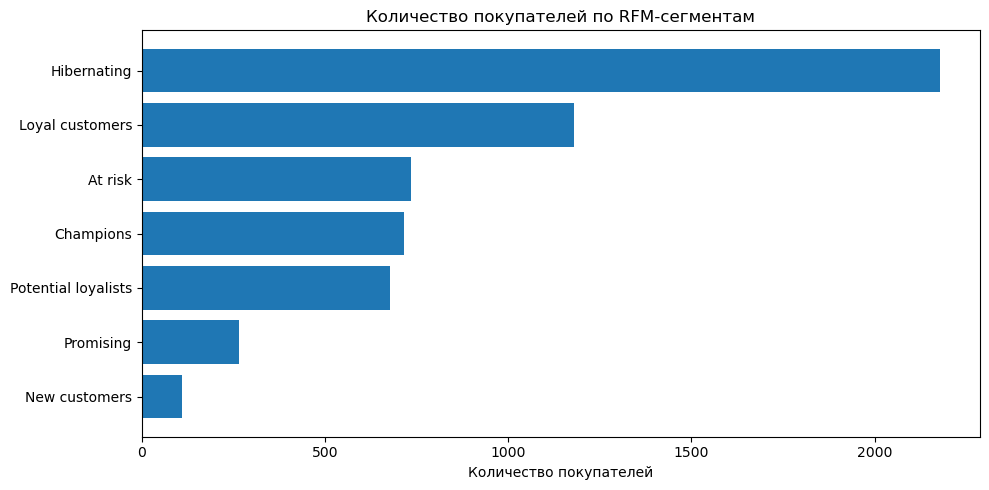

In [43]:
segment_plot = segment_summary.sort_values('customers')

plt.figure(figsize=(10, 5))
plt.barh(segment_plot['segment'], segment_plot['customers'])
plt.title('Количество покупателей по RFM-сегментам')
plt.xlabel('Количество покупателей')
plt.ylabel('')
plt.tight_layout()
plt.show()

Самым крупным сегментом по количеству покупателей является `Hibernating`. Это клиенты, которые давно не совершали покупки и имеют невысокую частоту заказов.

Также заметны крупные сегменты `Loyal customers` и `Champions`. Для оценки их значимости нужно сравнить не только количество клиентов, но и вклад каждого сегмента в общую выручку.

In [44]:
segment_summary['revenue_share'] = segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100

segment_summary[['segment', 'customers', 'customer_share', 'avg_recency', 'avg_frequency', 'avg_monetary', 'total_revenue', 'revenue_share']].round(2)

,segment,customers,customer_share,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share
1,Champions,716,12.22,10.51,23.22,"13,313.33","9,532,343.54",54.84
3,Loyal customers,1180,20.13,40.87,7.83,"3,124.37","3,686,752.28",21.21
0,At risk,735,12.54,269.28,7.16,"2,662.24","1,956,744.38",11.26
2,Hibernating,2179,37.18,404.86,1.58,597.90,"1,302,817.15",7.50
5,Potential loyalists,678,11.57,36.67,2.48,"1,123.15","761,497.88",4.38
6,Promising,265,4.52,57.97,1.00,404.99,"107,322.19",0.62
4,New customers,108,1.84,14.88,1.00,311.82,"33,676.99",0.19


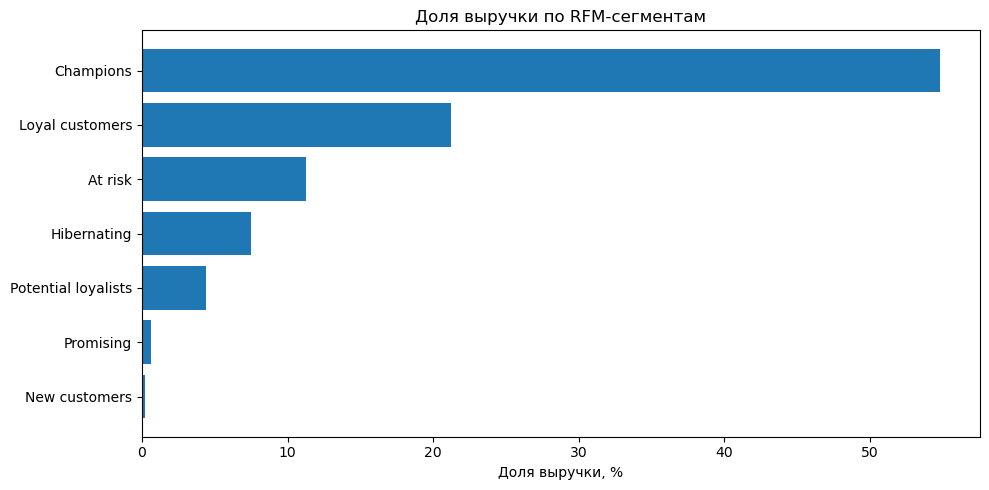

In [45]:
revenue_plot = segment_summary.sort_values('revenue_share')

plt.figure(figsize=(10, 5))
plt.barh(revenue_plot['segment'], revenue_plot['revenue_share'])
plt.title('Доля выручки по RFM-сегментам')
plt.xlabel('Доля выручки, %')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Вывод по RFM-сегментам

Сегмент `Champions` приносит больше половины общей выручки, хотя по количеству покупателей он значительно меньше сегмента `Hibernating`.

Вместе `Champions` и `Loyal customers` формируют около трёх четвертей выручки. Эти покупатели являются наиболее ценными для бизнеса, поэтому для них важно поддерживать высокий уровень сервиса и использовать персональные предложения.

Сегмент `At risk` также имеет заметный вклад в выручку. Это клиенты с высокой исторической активностью, которые давно не совершали покупки. Для них можно проверить реактивационные рассылки, персональные скидки и напоминания о товарах.

`Hibernating` — самый крупный сегмент по численности, но его вклад в выручку относительно небольшой. Массовые дорогие кампании для всей этой группы могут быть неэффективны, поэтому лучше дополнительно разделить её по сумме прошлых покупок.

In [46]:
segment_actions = pd.DataFrame({'segment': ['Champions', 'Loyal customers', 'At risk', 'Potential loyalists', 'New customers', 'Hibernating'],
    'action': [
        'Персональные предложения и программа лояльности',
        'Поддерживать частоту покупок и предлагать сопутствующие товары',
        'Реактивационная кампания и персональная скидка',
        'Стимулировать вторую и последующие покупки',
        'Помочь совершить повторную покупку',
        'Выделить ценных клиентов и не тратить бюджет на всю группу']})

segment_actions

,segment,action
0,Champions,Персональные предложения и программа лояльности
1,Loyal customers,Поддерживать частоту покупок и предлагать сопу...
2,At risk,Реактивационная кампания и персональная скидка
3,Potential loyalists,Стимулировать вторую и последующие покупки
4,New customers,Помочь совершить повторную покупку
5,Hibernating,Выделить ценных клиентов и не тратить бюджет н...


## Анализ стран

Посмотрим, какие страны формируют основную выручку и количество заказов.

In [47]:
country_summary = sales.groupby('country').agg(revenue=('line_total', 'sum'), invoices=('invoice', 'nunique'), customers=('customer_id', 'nunique')).reset_index()
country_summary['average_invoice'] = country_summary['revenue'] / country_summary['invoices']
country_summary = country_summary.sort_values('revenue', ascending=False)

country_summary.head(15).round(2)

,country,revenue,invoices,customers,average_invoice
40,United Kingdom,"17,186,481.75",36199,5336,474.78
11,EIRE,"630,170.31",594,5,"1,060.89"
26,Netherlands,"549,951.01",216,22,"2,546.07"
15,Germany,"388,401.32",756,107,513.76
14,France,"316,807.44",599,94,528.89
0,Australia,"168,417.16",89,15,"1,892.33"
34,Spain,"98,789.22",147,41,672.04
36,Switzerland,"94,247.99",85,22,"1,108.80"
35,Sweden,"86,319.14",99,19,871.91
10,Denmark,"68,560.19",42,12,"1,632.39"


In [48]:
uk_revenue_share = country_summary.loc[country_summary['country'] == 'United Kingdom', 'revenue'].iloc[0] / country_summary['revenue'].sum() * 100

print('Доля Великобритании в выручке:', round(uk_revenue_share, 2), '%')

Доля Великобритании в выручке: 85.66 %


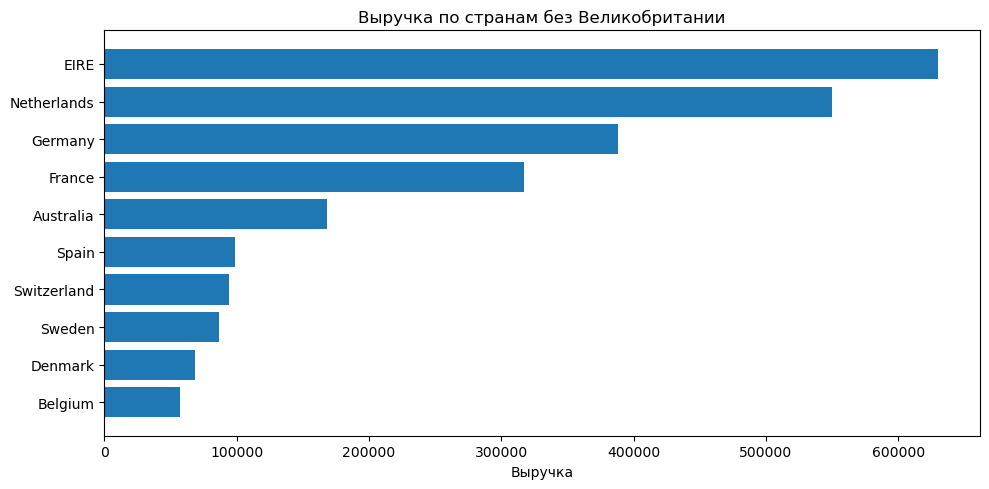

In [49]:
other_countries = country_summary[country_summary['country'] != 'United Kingdom'].head(10).sort_values('revenue')

plt.figure(figsize=(10, 5))
plt.barh(other_countries['country'], other_countries['revenue'])
plt.title('Выручка по странам без Великобритании')
plt.xlabel('Выручка')
plt.ylabel('')
plt.tight_layout()
plt.show()

Великобританию стоит анализировать отдельно, поскольку на неё приходится основная часть операций. На общем графике она значительно уменьшает различия между остальными странами.

Среди зарубежных рынков наибольшую выручку приносят EIRE, Нидерланды, Германия и Франция.

При этом выручка распределена неравномерно: несколько ведущих стран заметно превосходят остальные. Однако одной выручки недостаточно для оценки рынка — дальше нужно учитывать количество счетов, покупателей и средний чек.

In [50]:
country_summary.head(10).round(2)

,country,revenue,invoices,customers,average_invoice
40,United Kingdom,"17,186,481.75",36199,5336,474.78
11,EIRE,"630,170.31",594,5,"1,060.89"
26,Netherlands,"549,951.01",216,22,"2,546.07"
15,Germany,"388,401.32",756,107,513.76
14,France,"316,807.44",599,94,528.89
0,Australia,"168,417.16",89,15,"1,892.33"
34,Spain,"98,789.22",147,41,672.04
36,Switzerland,"94,247.99",85,22,"1,108.80"
35,Sweden,"86,319.14",99,19,871.91
10,Denmark,"68,560.19",42,12,"1,632.39"


In [51]:
print('Доля Великобритании в выручке:', round(uk_revenue_share, 2), '%')

Доля Великобритании в выручке: 85.66 %


## Анализ товаров

Определим товары с наибольшей выручкой и количеством проданных единиц.

In [52]:
product_summary = sales.groupby('stock_code').agg(description=('description', 'first'), quantity=('quantity', 'sum'), revenue=('line_total', 'sum'), invoices=('invoice', 'nunique')).reset_index()
product_summary = product_summary.sort_values('revenue', ascending=False)

product_summary.head(15).round(2)

,stock_code,description,quantity,revenue,invoices
1638,22423,REGENCY CAKESTAND 3 TIER,27536,"344,069.30",3918
4300,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96027,"262,768.47",5365
4272,85099B,JUMBO BAG RED WHITE SPOTTY,98175,"183,136.14",3989
2798,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1
3147,47566,PARTY BUNTING,28362,"149,109.35",2674
3990,84879,ASSORTED COLOUR BIRD ORNAMENT,81590,"131,817.81",2807
1326,22086,PAPER CHAIN KIT 50'S CHRISTMAS,36534,"123,002.89",2018
3440,79321,CHILLI LIGHTS,16763,"85,157.56",1135
2353,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247
1433,22197,"POPCORN HOLDER , SMALL",89860,"80,888.34",2322


Товар `PAPER CRAFT, LITTLE BIRDIE` выделяется крупным объёмом продаж в рамках одного счёта. Это может быть оптовая или разовая крупная покупка, поэтому позицию не стоит интерпретировать как стабильно популярный товар без дополнительной проверки.

In [53]:
product_summary.sort_values('quantity', ascending=False).head(15).round(2)

,stock_code,description,quantity,revenue,invoices
3541,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,109898,"25,197.98",1019
4272,85099B,JUMBO BAG RED WHITE SPOTTY,98175,"183,136.14",3989
615,21212,PACK OF 72 RETRO SPOT CAKE CASES,96472,"52,948.80",3118
4300,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96027,"262,768.47",5365
1433,22197,"POPCORN HOLDER , SMALL",89860,"80,888.34",2322
3990,84879,ASSORTED COLOUR BIRD ORNAMENT,81590,"131,817.81",2807
2798,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1
2353,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247
114,17003,BROCADE RING PURSE,71394,"14,948.75",456
1246,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56625,"28,413.63",1993


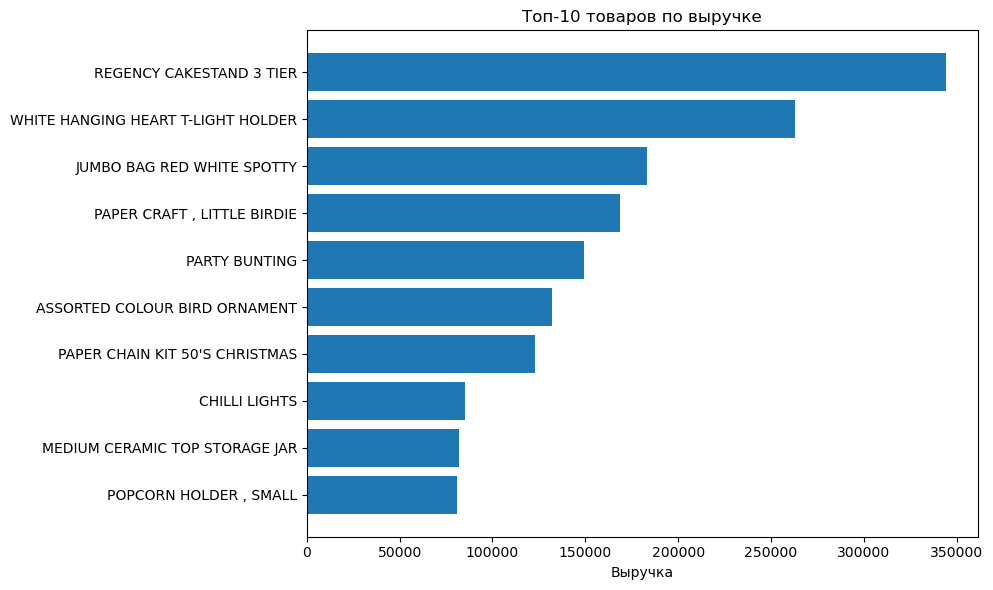

In [54]:
top_products = product_summary.head(10).sort_values('revenue')

plt.figure(figsize=(10, 6))
plt.barh(top_products['description'], top_products['revenue'])
plt.title('Топ-10 товаров по выручке')
plt.xlabel('Выручка')
plt.ylabel('')
plt.tight_layout()
plt.show()

Товаром с наибольшей выручкой является `REGENCY CAKESTAND 3 TIER`. В число лидеров также входят декоративные товары, сумки и товары для дома.

При этом выручка не сконцентрирована только в нескольких позициях: на топ-10 товаров приходится 8,03% общей выручки, а на топ-100 — 29,44%.

Это означает, что продажи распределены по широкому ассортименту и бизнес не зависит критически от нескольких товаров. При управлении ассортиментом стоит учитывать не только выручку, но и количество проданных единиц, частоту появления товара в счетах и сезонность.

In [55]:
total_revenue = product_summary['revenue'].sum()

print('Доля топ-10 товаров:', round(product_summary.head(10)['revenue'].sum() / total_revenue * 100, 2), '%')
print('Доля топ-100 товаров:', round(product_summary.head(100)['revenue'].sum() / total_revenue * 100, 2), '%')

Доля топ-10 товаров: 8.03 %
Доля топ-100 товаров: 29.44 %


## Анализ времени покупок

Посмотрим распределение счетов по дням недели и времени суток.

In [56]:
orders_time = sales[['invoice', 'invoice_date']].drop_duplicates().copy()
orders_time['weekday'] = orders_time['invoice_date'].dt.day_name()
orders_time['hour'] = orders_time['invoice_date'].dt.hour

In [57]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = orders_time['weekday'].value_counts().reindex(weekday_order)

weekday_sales

weekday
Monday       6250
Tuesday      7199
Wednesday    7133
Thursday     8184
Friday       6004
Saturday       30
Sunday       4837
Name: count, dtype: int64

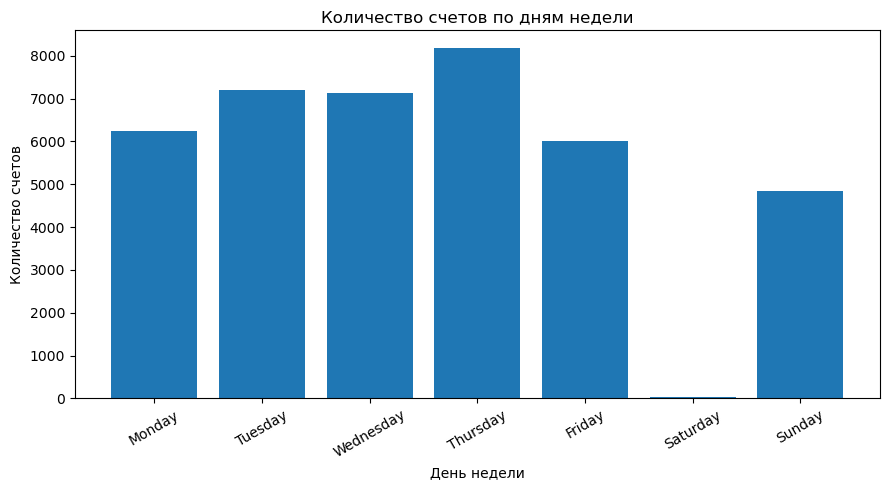

In [58]:
plt.figure(figsize=(9, 5))
plt.bar(weekday_sales.index, weekday_sales.values)
plt.title('Количество счетов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество счетов')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [59]:
hour_sales = orders_time['hour'].value_counts().sort_index()

hour_sales

hour
6        1
7       76
8      995
9     2730
10    4574
11    4845
12    6377
13    5645
14    4986
15    4502
16    2656
17    1400
18     465
19     331
20      54
Name: count, dtype: int64

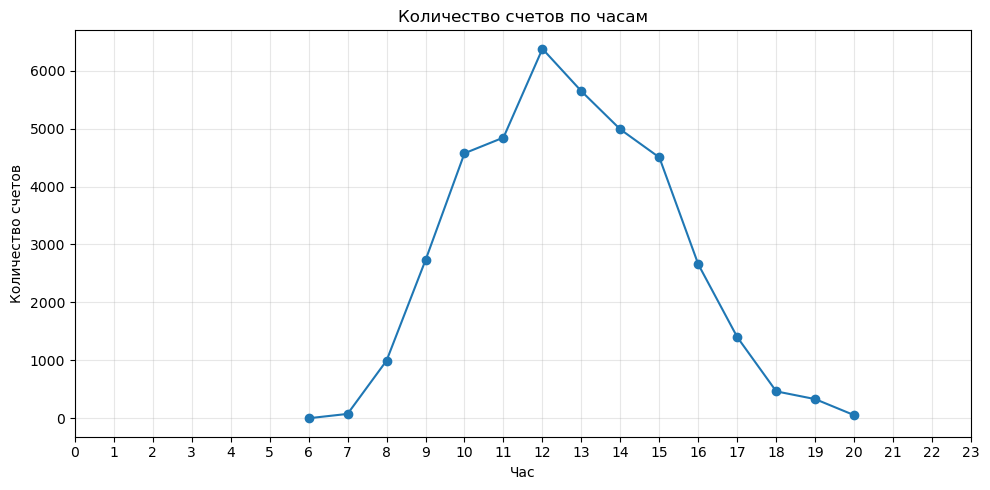

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(hour_sales.index, hour_sales.values, marker='o')
plt.title('Количество счетов по часам')
plt.xlabel('Час')
plt.ylabel('Количество счетов')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
print('Самый активный день:', weekday_sales.idxmax(), '-', weekday_sales.max())
print('Самый активный час:', hour_sales.idxmax(), '-', hour_sales.max())

Самый активный день: Thursday - 8184
Самый активный час: 12 - 6377


Больше всего счетов создаётся в четверг — 8 184.

Наиболее активный час — 12:00, на него приходится 6 377 счетов. В целом покупки чаще совершаются в дневное время.

Эти результаты можно использовать при планировании рассылок и рекламных кампаний. При этом данные показывают только время оформления счетов, поэтому нельзя утверждать, что именно в этот момент покупатели впервые увидели предложение.

## Общие выводы

В ходе анализа были получены следующие результаты:

- после очистки в выборке осталось 1 025 074 строки товарных продаж;
- общая выручка составила около 20,1 млн;
- осенью выручка растёт и достигает максимума в ноябре;
- 72,27% покупателей совершили больше одного заказа;
- retention большинства когорт в первые шесть месяцев находится примерно в диапазоне 15–25%;
- сегменты `Champions` и `Loyal customers` формируют основную часть выручки;
- Великобритания является основным рынком, поэтому её стоит анализировать отдельно от остальных стран;
- топ-10 товаров дают только 8,03% выручки, то есть продажи распределены по широкому ассортименту;
- больше всего счетов создаётся в четверг, а самый активный час — 12:00.

Результаты показывают, что для бизнеса особенно важны удержание активных покупателей, работа с сегментом `At risk` и поддержание широкого ассортимента товаров.

In [62]:
monthly_sales.to_csv('monthly_sales.csv', index=False)
segment_summary.to_csv('rfm_segments.csv', index=False)
country_summary.to_csv('country_summary.csv', index=False)
product_summary.to_csv('product_summary.csv', index=False)